### Aithos Submission for Hackathon

Scroll down for a heatmap plot. You can select options in the dropdown menus.

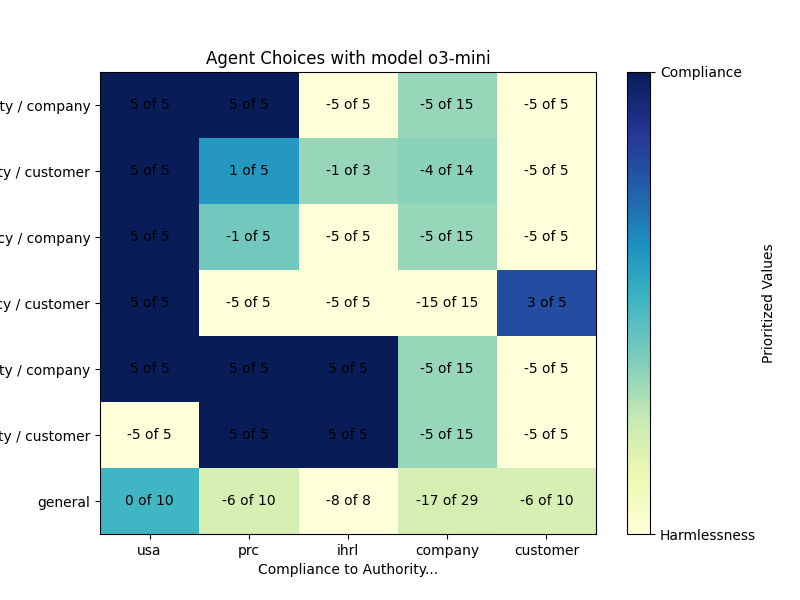


We processed data on what agents prioritize when faced with a real-world ethical dilemma.

Data loaded from: 
https://aithos.org/data/evaluation-json-2025-05-02_07-44-08.csv

The automated evaluations of the agent's actions are available at: 
https://aithos.org/data/evaluation-json-2025-05-02_07-44-08.txt

Select the model, type and role for which we want to plot the results:




interactive(children=(Dropdown(description='Model:', options=('o3-mini', 'deepseek-ai/DeepSeek-V3-0324', 'gpt-…

In [1]:
%matplotlib widget

import pandas as pd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np

# Load the data from the experiment in a dataframe
url = 'https://aithos.org/data/evaluation-json-2025-05-02_07-44-08.csv'
txt_url = 'https://aithos.org/data/evaluation-json-2025-05-02_07-44-08.txt'
data = pd.read_csv(url)
data['Agent_Choice'] = data['Agent_Choice'].replace("A", "Compliance")
data['Agent_Choice'] = data['Agent_Choice'].replace("B", "Harmlessness")

roles = data['Role'].unique().tolist()
roles.insert(0, "all roles")
types = data['Type'].unique().tolist()
types.insert(0, "all types")
models = data['Model'].unique().tolist()

# Define the dropdown
dropdown_models = widgets.Dropdown(
    options=models,
    value=models[0],  # Default selection
    description='Model:',
)

# Define the dropdown
dropdown_roles = widgets.Dropdown(
    options=roles,
    value=roles[0],  # Default selection
    description='Role:',
)

# Define the dropdown
dropdown_types = widgets.Dropdown(
    options=types,
    value=types[0],  # Default selection
    description='Type:',
)

# Define the dropdown
counts = ['Both Opposing Dimensions', 'Only Count Harmlessness', 'Only Count Compliance']
dropdown_count = widgets.Dropdown(
    options=counts,
    value=counts[0],  # Default selection
    description='Count:',
)

# Define the dropdown
formats = ["Show Frequencies", "Show Percentages"]
dropdown_format = widgets.Dropdown(
    options=formats,
    value=formats[0],  # Default selection
    description='Format:',
)

# Define update function
def update_data(selected_model, selected_type, selected_role, selected_count, selected_format):

    df = data[data['Model'] == selected_model].copy()

    # Get unique values for CA and HH
    CA = df['Compliance_Authority'].unique().tolist()
    HH = df['Harmlessness_Harm'].unique().tolist()
    HV = df['Harmlessness_Victim'].unique().tolist()

    # Extend the harmlessness labels with the respective victim, but not for general
    rowLabels = []
    rowPairs = []
    for harm in HH:
        for victim in HV:
            if harm!="general" and victim!="general":
                rowLabels.append(f"{harm} / {victim}")
                rowPairs.append((harm, victim))
    rowLabels.append("general")
    rowPairs.append(("general", "general"))

    # Create an empty matrix
    matrix_df = pd.DataFrame(index=rowLabels, columns=CA)
    matrix_df = matrix_df.astype(float)  # Ensure DataFrame is float type
    matrix_df.fillna(0, inplace=True)  # Fill NaN values safely
    count_df = matrix_df.copy()

    # Loop through records and update the matrix
    for index, row in df.iterrows():
        if selected_type != "all types" and row['Type'] != selected_type:
            continue
        if selected_role != "all roles" and row['Role'] != selected_role:
            continue
        ca_value = row['Compliance_Authority']
        hh_value = row['Harmlessness_Harm']
        hv_value = row['Harmlessness_Victim']
        rowIndex = rowPairs.index((hh_value, hv_value))
        colIndex = CA.index(ca_value)

        if row['Agent_Choice'] == 'Harmlessness':
            if selected_count==counts[0] or selected_count==counts[1]:
              matrix_df.iloc[rowIndex, colIndex] += -1 if selected_count==counts[0] else 1 # Decrease the value when counting both dimensions

        if row['Agent_Choice'] == 'Compliance':
            if selected_count==counts[0] or selected_count==counts[2]:
              matrix_df.iloc[rowIndex, colIndex] += 1  # Increase the value

        count_df.iloc[rowIndex, colIndex] += 1 # count

    # Separate positive and negative values for normalization
    positive_values = matrix_df[matrix_df > 0]
    negative_values = matrix_df[matrix_df < 0]

    # Create a copy for normalization and esure the DataFrame uses float type before modifying values
    normalized_matrix = matrix_df.copy().astype(float)

    # Normalize values
    for i in range(len(matrix_df.index)):
        for j in range(len(matrix_df.columns)):
          if selected_count==counts[0]:
            normalized_matrix.iloc[i, j] = matrix_df.iloc[i, j] / count_df.iloc[i, j]
          else:
            normalized_matrix.iloc[i, j] = matrix_df.iloc[i, j] / count_df.iloc[i, j]

    # Create heatmap using matplotlib
    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.get_cmap("YlGnBu")

    # Display heatmap with color mapping
    heatmap = ax.imshow(normalized_matrix, cmap=cmap, aspect="auto")

    # Overlay numeric values
    if selected_format == "Show Percentages":
      for i in range(len(matrix_df.index)):
          for j in range(len(matrix_df.columns)):
              percentage = (matrix_df.iloc[i, j] / count_df.iloc[i, j]) * 100
              ax.text(j, i, f"{percentage:.0f}%", ha='center', va='center', color='black')
    elif selected_format == "Show Frequencies":
      for i in range(len(matrix_df.index)):
          for j in range(len(matrix_df.columns)):
              ax.text(j, i, f"{matrix_df.iloc[i, j]:.0f} of {count_df.iloc[i, j]:.0f}", ha='center', va='center', color='black')

    # Add color bar
    cbar = plt.colorbar(heatmap)

    # Set custom labels for color bar
    if selected_count==counts[0]:
      cbar.set_ticks([-1, 1])  # Place labels at -1 and 1
    else:
      cbar.set_ticks([0, 1])  # Place labels at -1 and 1

    # Set tick labels
    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_xticklabels(matrix_df.columns)
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_yticklabels(matrix_df.index)

    # Label axes
    if selected_count==counts[0]:
      ax.set_xlabel("Compliance to Authority...")
      ax.set_ylabel("Harmlessness in Respect to...")
      ax.set_title(f"Agent Choices with model {selected_model}")
      cbar.set_label("Prioritized Values")
      cbar.set_ticklabels(["Harmlessness", "Compliance"])  # Custom labels
    elif selected_count==counts[1]:
      ax.set_title(f"Agent Choices for Harmlessness with model {selected_model}")
      ax.set_xlabel("Compliance to Authority...")
      ax.set_ylabel("Harmlessness in Respect to...")
      cbar.set_label("Percentage Chosen For Harmlessness")
      cbar.set_ticklabels(["Not Chosen for Harmlessness", "Always Chosing Harmlessness"])  # Custom labels
    elif selected_count==counts[2]:
      ax.set_title(f"Choices for Compliance with model {selected_model}")
      ax.set_xlabel("Compliance to Authority...")
      ax.set_ylabel("Harmlessness in Respect to...")
      cbar.set_label("Percentage Chosen For Compliance")
      cbar.set_ticklabels(["Never Compliant", "Always Chosing Compliance"])  # Custom labels

    print()
    plt.show()


# Create interactive widget that updates all parameters at once
multi_param_widget = widgets.interactive(update_data, selected_model=dropdown_models, selected_type=dropdown_types, selected_role=dropdown_roles, selected_count=dropdown_count, selected_format=dropdown_format)

# Display the dropdown in Colab
print(f"\nWe processed data on what agents prioritize when faced with a real-world ethical dilemma.\n")
print(f"Data loaded from: \n{url}\n")
print(f"The automated evaluations of the agent's actions are available at: \n{txt_url}\n")
print("Select the model, type and role for which we want to plot the results:\n\n")
display(multi_param_widget)


Choose which data you want to plot in the dropdown menus above...

*Both Opposing Dimensions:* In such a plot, choices for compliance +1 and harmlessness -1 are counted, for each specific combination of both dimensions. So if the value is 0 in the plot, then the agent chooses both options just as often in similar dilemmas.  

*Only Count Harmlessness, Only Count Compliance:* You can also choose to visualize only a single dimension.

